In [8]:
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 300

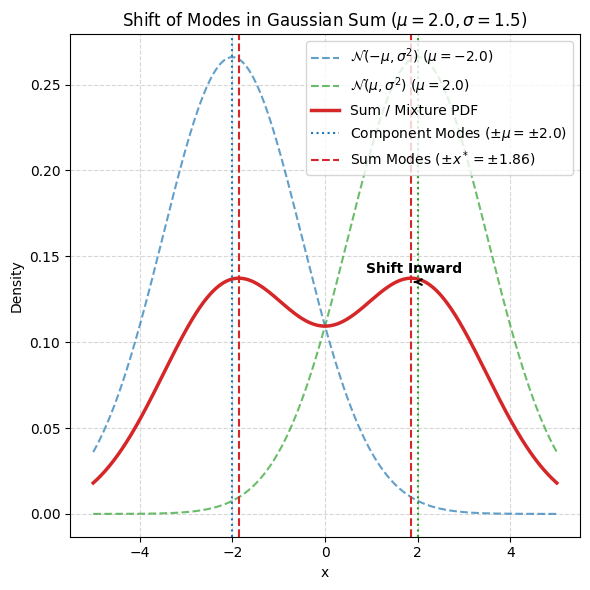

In [11]:
import numpy as np
from scipy.optimize import root_scalar

# Parameters
mu = 2.0
sigma = 1.5

# Grid
x = np.linspace(-5, 5, 1000)

# PDFs
pdf_neg = (1 / (np.sqrt(2 * np.pi) * sigma)) * np.exp(-0.5 * ((x + mu) / sigma)**2)
pdf_pos = (1 / (np.sqrt(2 * np.pi) * sigma)) * np.exp(-0.5 * ((x - mu) / sigma)**2)
pdf_sum = 0.5 * (pdf_neg + pdf_pos)

# Exact mode equation
def mode_eq(x_val):
    return mu * np.tanh(mu * x_val / (sigma**2)) - x_val

mode_pos = root_scalar(mode_eq, bracket=[0.01, mu]).root
mode_neg = -mode_pos

# Plot
plt.figure(figsize=(6, 6), dpi=100)

plt.plot(x, pdf_neg, '--', color='tab:blue', alpha=0.7, label=rf'$\mathcal{{N}}(-\mu, \sigma^2)$ ($\mu = -2.0$)')
plt.plot(x, pdf_pos, '--', color='tab:green', alpha=0.7, label=rf'$\mathcal{{N}}(\mu, \sigma^2)$ ($\mu = 2.0$)')
plt.plot(x, pdf_sum, '-', color='tab:red', lw=2.5, label='Sum / Mixture PDF')

# Mark original modes
plt.axvline(-mu, color='tab:blue', linestyle=':', lw=1.5, label=rf'Component Modes ($\pm \mu = \pm 2.0$)')
plt.axvline(mu, color='tab:green', linestyle=':', lw=1.5)

# Mark shifted sum modes
plt.axvline(mode_neg, color='tab:red', linestyle='--', lw=1.5, label=rf'Sum Modes ($\pm x^* = \pm {mode_pos:.2f}$)')
plt.axvline(mode_pos, color='tab:red', linestyle='--', lw=1.5)

# Add annotations/arrows
plt.annotate(
    '', xy=(mode_pos, 0.135), xytext=(mu, 0.135),
    arrowprops=dict(arrowstyle='->', color='black', lw=1.5)
)
plt.text((mu + mode_pos) / 2, 0.14, 'Shift Inward', ha='center', fontsize=10, fontweight='bold')

plt.title(rf'Shift of Modes in Gaussian Sum ($\mu = {mu}, \sigma = {sigma}$)', fontsize=12)
plt.xlabel('x')
plt.ylabel('Density')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('../Thesis/figures/ridge_gaussian.png', dpi=300, bbox_inches='tight')
plt.show()